In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from mlxtend.plotting import plot_decision_regions 

from pylab import rcParams
import warnings

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles


In [15]:
x,y = make_circles(n_samples=100,noise=0.1,random_state=2)

<Axes: >

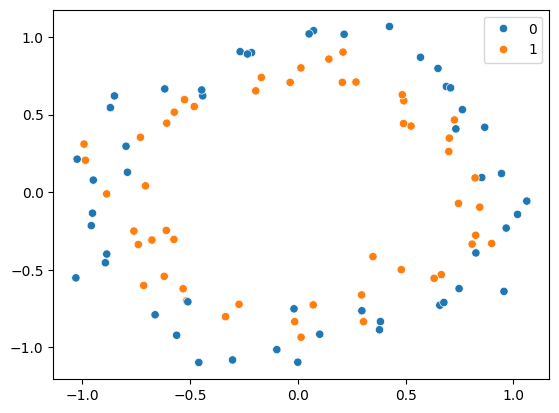

In [16]:
sns.scatterplot(x=x[:,0],y=x[:,1],hue=y)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=2)

In [18]:
model = Sequential()

model.add(Dense(256,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

In [19]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [20]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=3500)

Epoch 1/3500
3/3 [==============================] - 0s 66ms/step - loss: 0.6995 - accuracy: 0.5000 - val_loss: 0.6938 - val_accuracy: 0.6000
Epoch 2/3500
3/3 [==============================] - 0s 18ms/step - loss: 0.6973 - accuracy: 0.4750 - val_loss: 0.6945 - val_accuracy: 0.5000
Epoch 3/3500
3/3 [==============================] - 0s 24ms/step - loss: 0.6955 - accuracy: 0.4750 - val_loss: 0.6952 - val_accuracy: 0.4500
Epoch 4/3500
3/3 [==============================] - 0s 21ms/step - loss: 0.6941 - accuracy: 0.4625 - val_loss: 0.6975 - val_accuracy: 0.4000
Epoch 5/3500
3/3 [==============================] - 0s 23ms/step - loss: 0.6929 - accuracy: 0.5500 - val_loss: 0.6991 - val_accuracy: 0.4000
Epoch 6/3500
3/3 [==============================] - 0s 23ms/step - loss: 0.6918 - accuracy: 0.5250 - val_loss: 0.6998 - val_accuracy: 0.4000
Epoch 7/3500
3/3 [==============================] - 0s 24ms/step - loss: 0.6916 - accuracy: 0.5125 - val_loss: 0.7015 - val_accuracy: 0.4000
Epoch 8/3500


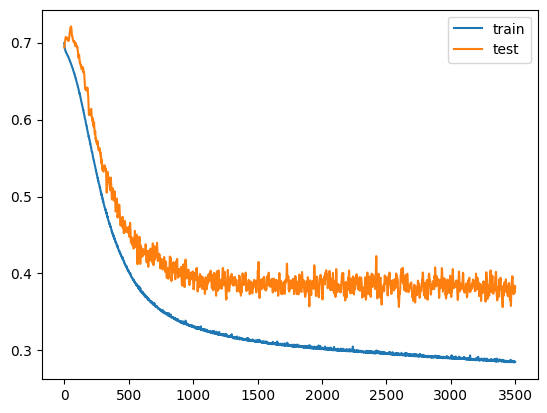

In [21]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 [==============================] - 12s 1ms/step


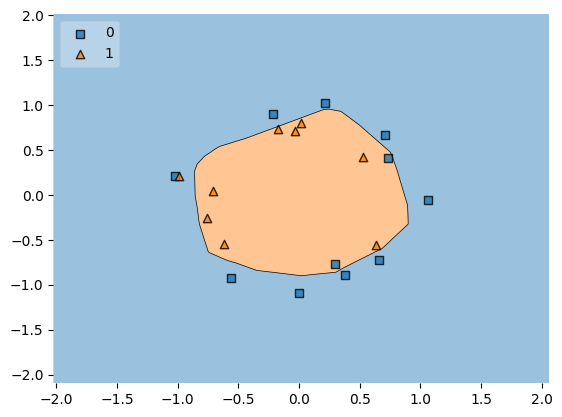

In [22]:
plot_decision_regions(x_test,y_test.ravel(),clf=model,legend=2)
plt.show()

# Early Stopping

In [23]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [24]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [25]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [26]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=3500,callbacks=callback)

Epoch 1/3500
3/3 [==============================] - 0s 65ms/step - loss: 0.6965 - accuracy: 0.4750 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 2/3500
3/3 [==============================] - 0s 20ms/step - loss: 0.6942 - accuracy: 0.5000 - val_loss: 0.6953 - val_accuracy: 0.4500
Epoch 3/3500
3/3 [==============================] - 0s 19ms/step - loss: 0.6930 - accuracy: 0.5250 - val_loss: 0.6979 - val_accuracy: 0.4000
Epoch 4/3500
3/3 [==============================] - 0s 20ms/step - loss: 0.6917 - accuracy: 0.5250 - val_loss: 0.6994 - val_accuracy: 0.4000
Epoch 5/3500
3/3 [==============================] - 0s 20ms/step - loss: 0.6907 - accuracy: 0.5250 - val_loss: 0.7002 - val_accuracy: 0.4000
Epoch 6/3500
3/3 [==============================] - 0s 22ms/step - loss: 0.6899 - accuracy: 0.5250 - val_loss: 0.7028 - val_accuracy: 0.4000
Epoch 7/3500
3/3 [==============================] - 0s 22ms/step - loss: 0.6891 - accuracy: 0.5375 - val_loss: 0.7052 - val_accuracy: 0.3000
Epoch 8/3500


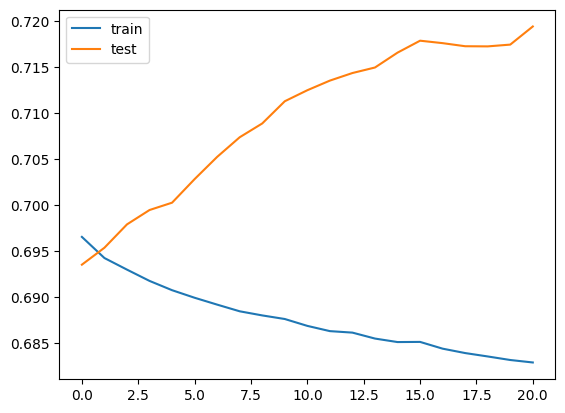

In [27]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 [==============================] - 11s 1ms/step


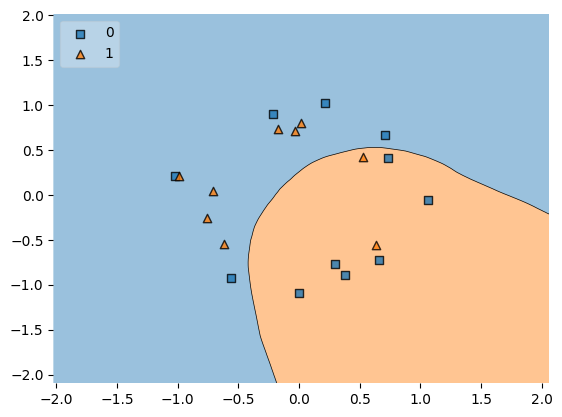

In [28]:
plot_decision_regions(x_test, y_test.ravel(), clf = model, legend=2)
plt.show()